<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Vacuum Neutrino Analysis 2 -- Experimental Regimes and Flux
---
This notebook applies the vacuum oscillation framework to three experimental regimes:
- reactor antineutrinos
- long-baseline accelerator beams (T2K, NOvA, DUNE)
- atmospheric neutrinos.

It uses the `vacuum_flux_state` API to propagate spectral fluxes to the detector,
illustrating how the oscillation maximum depends on both energy and baseline.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theory-Background) | **Theory Background** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Configuration) | **Configuration** |
| [3](#3.-Reactor-Antineutrinos) | **Reactor Antineutrinos** |
| [4](#4.-Long-Baseline-Accelerator) | **Long-Baseline Accelerator** |
| [5](#5.-Atmospheric-Neutrinos-(Propagating-in-Vacuum)) | **Atmospheric Neutrinos (Propagating in Vacuum)** |
| [6](#6.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 Reactor Antineutrino Sources

Nuclear reactors produce $\bar\nu_e$ from beta decay of fission products. The emitted spectrum
peaks around $E \sim 3$--$4\,\mathrm{MeV}$. For illustration, this notebook uses a simple
inverse-beta-decay-weighted toy spectrum above the $1.8\,\mathrm{MeV}$ threshold [Vogel--Beacom 1999]:

$$
\frac{dN}{dE} \propto (E - 1.8)^2 \cdot E^{-1}, \qquad E > 1.8 \; \text{MeV}
$$

Two distinct oscillation effects are relevant:
- At short baselines ($L \lesssim 2\,\mathrm{km}$): $\Delta m^2_{31}$ drives the leading rapid oscillation of $\bar\nu_e$
  survival.
- At medium baselines ($L \sim 50\,\mathrm{km}$, e.g. JUNO): interference between the solar and atmospheric oscillation scales provides mass-ordering sensitivity.
- At long baselines ($L \sim 180\,\mathrm{km}$, KamLAND): the signal is primarily sensitive to $\Delta m^2_{21}$ and $\theta_{12}$.

### 0.2 Accelerator Neutrino Beams

Long-baseline accelerator facilities produce a predominantly $\nu_\mu$ or $\bar\nu_\mu$ beam from focused pion and kaon decays. Near detectors constrain the unoscillated flux and interactions; a far detector measures the flavour and energy spectrum after propagation. The leading atmospheric-scale term contains $\sin^2(1.2669\,\Delta m^2_{31}L/E)$, so its first maximum satisfies [PDG 2025]:

$$
1.2669\,\frac{|\Delta m^2_{31}|[\mathrm{eV}^2]L[\mathrm{km}]}{E_{\rm peak}[\mathrm{GeV}]}=\frac{\pi}{2},\qquad
E_{\rm peak}[\mathrm{GeV}]=\frac{2\times1.2669}{\pi}|\Delta m^2_{31}|[\mathrm{eV}^2]L[\mathrm{km}].
$$

For $|\Delta m^2_{31}|=2.51\times10^{-3}\,\mathrm{eV}^2$, this gives approximately 0.60, 1.64 and 2.63 GeV at the T2K, NOvA and DUNE baselines, respectively. These are oscillation-optimum energies, not necessarily the exact peaks of the engineered beams.

#### Reactor-detector labels used in this notebook

1. **Short-baseline example ($1.5\,\mathrm{km}$).** This is an illustrative baseline representative of the far-detector scale of $\theta_{13}$ reactor experiments; it is not a separately named experiment.
2. **Daya Bay.** The Daya Bay experiment in China used multiple reactor cores and near and far detector halls. Its far halls were at kilometre-scale baselines.
3. **JUNO-like medium baseline ($50\,\mathrm{km}$).** The $50\,\mathrm{km}$ marker used below belongs physically to the medium-baseline regime represented by JUNO.
4. **KamLAND ($180\,\mathrm{km}$ effective baseline).** KamLAND in Japan observed antineutrinos from many commercial reactors and measured the solar oscillation scale.

#### Experiments

1. **T2K (Tokai to Kamioka).** A 295 km experiment using a $2.5^\circ$ off-axis, narrow-band beam peaked near $0.6\,\mathrm{GeV}$ and the Super-Kamiokande water-Cherenkov far detector. It measures $\nu_\mu$ disappearance and $\nu_e$ appearance near the first maximum [T2K 2013].
2. **NOvA (NuMI Off-axis $\nu_e$ Appearance).** An 810 km experiment with functionally similar segmented liquid-scintillator near and far detectors. Its off-axis NuMI beam is concentrated around 2 GeV; the longer baseline gives more matter-effect and mass-ordering sensitivity than T2K [NOvA 2019].
3. **DUNE (Deep Underground Neutrino Experiment).** A planned 1300 km experiment using a wide-band beam from Fermilab to liquid-argon time-projection chambers at SURF. Its spectral coverage includes the first maximum and part of the second, supporting measurements of CP violation and the mass ordering [DUNE 2020].

#### Disappearance and appearance measurements

1. **Disappearance:** compare the observed $\nu_\mu$ or $\bar\nu_\mu$ spectrum with the no-oscillation expectation. A deficit constrains mainly $|\Delta m^2_{32}|$ and $\theta_{23}$ through $P(\nu_\mu\rightarrow\nu_\mu)$.
2. **Appearance:** search for a flavour that was strongly suppressed in the initial beam, principally $\nu_e$ or $\bar\nu_e$ in a muon-neutrino beam. $P(\nu_\mu\rightarrow\nu_e)$ is sensitive to $\theta_{13}$, $\theta_{23}$, $\delta_{\rm CP}$ and matter effects.
3. **Combined analysis:** experiments fit neutrino and antineutrino disappearance and appearance simultaneously. This helps separate correlated effects and parameter degeneracies.

#### Associated concepts

- **MO sensitivity (mass-ordering sensitivity):** ability to distinguish the sign of $\Delta m^2_{31}$, i.e. normal from inverted ordering. In long-baseline experiments it is generated mainly by energy-dependent matter effects. It is not reproduced by the vacuum-only calculations in this notebook.
- **Off-axis narrow-band beam:** observing the decay beam at a small angle produces a relatively narrow energy distribution centred near the first maximum. T2K and NOvA use this strategy to suppress high-energy backgrounds.
- **Wide-band beam:** covers a broad energy interval instead of concentrating events around one energy. DUNE can therefore use the shape of the oscillated spectrum rather than only one region near its maximum.
- **First and second oscillation maxima visible:** a wide energy range can resolve the first appearance maximum and obtain information around the second. The second maximum occurs at roughly one third of the first-maximum energy and has larger relative CP-dependent interference, although fewer events. "Full oscillation maximum visible" should be understood as spectral coverage around a maximum, not as a separate physical observable.

#### Comparison

| Experiment | Baseline | Beam and far detector | Representative beam energy | $E_{\rm peak}$ from vacuum formula | Principal channels | Main design advantage |
|---|---:|---|---:|---:|---|---|
| T2K | 295 km | Off-axis narrow-band; Super-K water Cherenkov | 0.6 GeV | 0.60 GeV | $\nu_\mu$ disappearance; $\nu_e$ appearance | High statistics near the first maximum and low matter-effect contamination |
| NOvA | 810 km | Off-axis narrow-band; segmented liquid scintillator | $1.8$--$2.0\,\mathrm{GeV}$ | $1.64\,\mathrm{GeV}$ | $\nu_\mu$ disappearance; $\nu_e$ appearance | Longer baseline gives moderate matter-effect and MO sensitivity |
| DUNE | 1300 km | Wide-band; liquid-argon TPC | $\sim 2.5\,\mathrm{GeV}$ | $2.63\,\mathrm{GeV}$ | $\nu_\mu$ disappearance; $\nu_e$ appearance | Strong matter effects and energy coverage around first and second maxima |

### 0.3 Atmospheric Neutrino Geometry

Atmospheric neutrinos are produced by cosmic-ray interactions in the upper atmosphere (height
$h \approx 20$ km). The baseline from production to an underground detector depends on the
zenith angle $\theta_z$:

$$
L(\theta_z) = \sqrt{(R_E+h)^2 - R_E^2 \sin^2\theta_z} - R_E \cos\theta_z
$$

where $R_E = 6371$ km. This gives $L \approx 20$ km for near-vertical downgoing neutrinos
($\cos\theta_z = +1$) and $L \approx 12\,740$ km for vertically upgoing neutrinos
($\cos\theta_z = -1$, traversing the full Earth diameter).

### 0.4 `vacuum_flux_state` API

`vacuum_flux_state(nustate, oscillation, E_MeV, L_km, flux, spectrum=None)` returns the oscillated
flux per flavour:

$$
\Phi^{(\beta)}(E) = P(\nu_\alpha \to \nu_\beta) \times \Phi_0(E)
$$

where `flux` is the total normalisation $\Phi_0$ and `spectrum` is the optional spectral weight
$s(E)$ such that the integrated spectrum equals 1. If `spectrum=None`, a flat spectrum is used.



**References**

- [1] P. Vogel and J. F. Beacom, *Angular distribution of neutron inverse beta decay, $\bar{\nu}_e+p\to e^++n$*, Phys. Rev. D **60**, 053003 (1999), arXiv:hep-ph/9903554.
- [2] Particle Data Group, *Neutrino Masses, Mixing, and Oscillations*, Review of Particle Physics (2025), Eq. (14.40) and the discussion of the first atmospheric oscillation maximum.
- [3] T2K Collaboration, *Measurement of Neutrino Oscillation Parameters from Muon Neutrino Disappearance with an Off-axis Beam*, Phys. Rev. Lett. **111**, 211803 (2013), arXiv:1308.0465.
- [4] NOvA Collaboration, *First Measurement of Neutrino Oscillation Parameters Using Neutrinos and Antineutrinos by NOvA*, Phys. Rev. Lett. **123**, 151803 (2019), arXiv:1906.04907.
- [5] DUNE Collaboration, *Deep Underground Neutrino Experiment (DUNE), Far Detector Technical Design Report, Volume I: Introduction to DUNE*, JINST **15**, T08008 (2020), arXiv:2002.02967.


## 1. Libraries

In [1]:
from __future__ import annotations

import dataclasses
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.vacuum.probability import vacuum_probability_transition, vacuum_probability_state
from tpeanuts.medium.vacuum.flux import vacuum_flux_state
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_LABELS, FLAVOUR_COLORS, to_numpy, save_and_show,
)
from tpeanuts.util.context import RuntimeContext
from tpeanuts.util.math import numpy_trapezoid


## 2. Configuration

### 2.1 Paths

In [2]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "vacuum")
SHOW_PLOTS = config.show_plots

print("Output directory:", OUTPUT_DIR)

Output directory: v:\output\analysis\vacuum


### 2.2 Configuration

Experiments dictionary with baseline, beam energy, and display color.
Reactor-baseline dictionary for comparison at short, medium, and long distances. The $50\,\mathrm{km}$ entry is JUNO-like and is not a Daya Bay baseline.

In [3]:
osc     = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", antinu=False, context=ctx)
osc_bar = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", antinu=True,  context=ctx)

# Long-baseline experiments
EXPERIMENTS = {
    "T2K":  {"L_km": 295,  "E_peak_GeV": 0.6,  "color": "C0"},
    "NOvA": {"L_km": 810,  "E_peak_GeV": 1.64,  "color": "C1"},
    "DUNE": {"L_km": 1300, "E_peak_GeV": 2.63,  "color": "C2"},
}

# Reactor detectors
REACTOR_DETECTORS = {
    "Short baseline (1.5 km)": {"L_km": 1.5,   "color": "C0", "ls": "-"},
    "JUNO-like (50 km)":      {"L_km": 50.0,  "color": "C1", "ls": "--"},
    "KamLAND (180 km)":   {"L_km": 180.0, "color": "C2", "ls": ":"},
}

R_E = 6371.0   # Earth radius [km]
H_ATM = 20.0   # Production height [km]

def baseline_from_zenith(cos_theta_z: float) -> float:
    # Compute atmospheric baseline in km from cosine of zenith angle
    sin_theta_z = math.sqrt(max(0.0, 1.0 - cos_theta_z**2))
    return math.sqrt((R_E + H_ATM)**2 - (R_E * sin_theta_z)**2) - R_E * cos_theta_z

print("Experiment baselines:")
for name, props in EXPERIMENTS.items():
    print(f"  {name}: L={props['L_km']} km, E_peak={props['E_peak_GeV']} GeV")

print("\nAtmospheric baselines:")
for cz in [-1.0, 0.0, 0.5, 0.9]:
    print(f"  cos(theta_z)={cz:+.1f} -> L={baseline_from_zenith(cz):.0f} km")

Experiment baselines:
  T2K: L=295 km, E_peak=0.6 GeV
  NOvA: L=810 km, E_peak=1.64 GeV
  DUNE: L=1300 km, E_peak=2.63 GeV

Atmospheric baselines:
  cos(theta_z)=-1.0 -> L=12762 km
  cos(theta_z)=+0.0 -> L=505 km
  cos(theta_z)=+0.5 -> L=40 km
  cos(theta_z)=+0.9 -> L=22 km


## 3. Reactor Antineutrinos

### 3.1 $\bar{\nu}_e$ Survival vs Baseline

$\bar{\nu}_e$ survival probability as a function of baseline at fixed effective energy $E=3\,\mathrm{MeV}$. Three
distances are marked: a short-baseline detector ($1.5\,\mathrm{km}$), a medium-baseline example ($50\,\mathrm{km}$), and KamLAND ($180\,\mathrm{km}$).

**Expected results:** 
- At $1.5\,\mathrm{km}$ the probability is close to 1.
- At $50\,\mathrm{km}$ both oscillation scales contribute.
- At $180\,\mathrm{km}$ the dominant modulation is driven by $\Delta m^2_{21}$ (solar splitting), characteristic of the KamLAND signal.

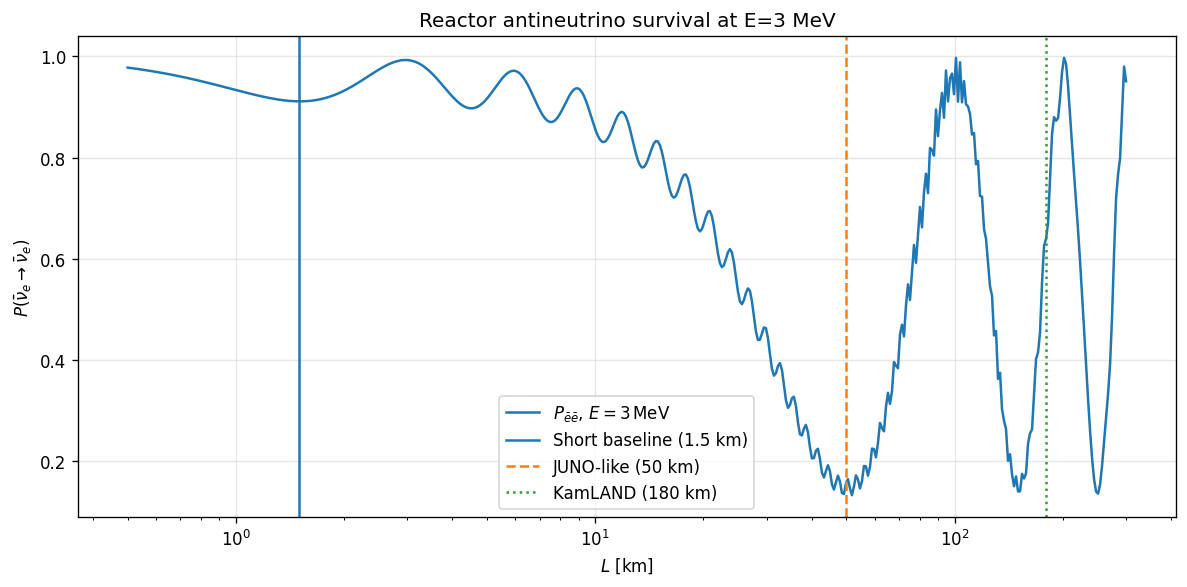

v:\output\analysis\vacuum\vf2_fig31_1_reactor_vs_L.png


In [4]:
E_reactor = torch.tensor(3.0, dtype=ctx.dtype, device=ctx.device)   # MeV
L_reactor = torch.logspace(math.log10(0.5), math.log10(300.0), 500,
                            dtype=ctx.dtype, device=ctx.device)

P_ee_bar = to_numpy(vacuum_probability_transition(osc_bar, E_reactor, L_reactor)[:, 0, 0])
L_r_np   = to_numpy(L_reactor)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(L_r_np, P_ee_bar, color="C0", label=r"$P_{\bar{e}\bar{e}}$, $E=3\,\mathrm{MeV}$")
for name, props in REACTOR_DETECTORS.items():
    ax.axvline(props["L_km"], color=props["color"], ls=props["ls"], label=name)
ax.set_xlabel(r"$L$ [km]")
ax.set_ylabel(r"$P(\bar\nu_e \to \bar\nu_e)$")
ax.set_title("Reactor antineutrino survival at E=3 MeV")
ax.legend()
fig.tight_layout()
save_and_show("vf2_fig31_1_reactor_vs_L.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.2 Universal L/E Plot

$P(\bar{\nu}_e\to\bar{\nu}_e)$ vs $L/E$ reveals both oscillation scales on a single axis. This is the characteristic
observable used by reactor experiments since it scales out the energy dependence.

**Expected results:** Two dips appear:
- The first from $\Delta m^2_{31}$ at $L/E \approx 500\,\mathrm{km/GeV}$ ($\approx 0.5\,\mathrm{km/MeV}$),
- The deeper dip from $\Delta m^2_{21}$ at $L/E \approx 20\,000\,\mathrm{km/GeV}$ ($20\,\mathrm{km/MeV}$), corresponding to the
KamLAND measurement.

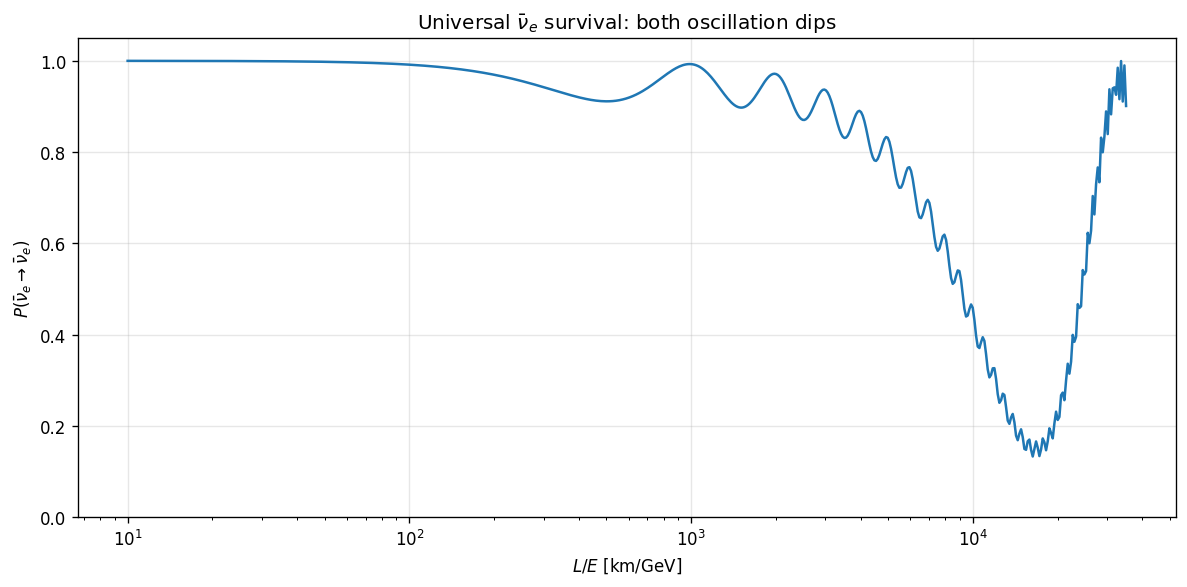

v:\output\analysis\vacuum\vf2_fig32_1_reactor_vs_LoverE.png


In [5]:
# L/E grid spanning both oscillation dips
LoE_grid = np.logspace(math.log10(10.0), math.log10(35000.0), 600)  # km/GeV = m/MeV * 1000

# Use a fixed E and vary L = LoE * E
E_fix_MeV = 3.0
L_from_LoE = torch.tensor(LoE_grid * E_fix_MeV * 1e-3, dtype=ctx.dtype, device=ctx.device)  # km
E_fix_t    = torch.tensor(E_fix_MeV, dtype=ctx.dtype, device=ctx.device)

P_ee_LoE = to_numpy(vacuum_probability_transition(osc_bar, E_fix_t, L_from_LoE)[:, 0, 0])

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(LoE_grid, P_ee_LoE, color="C0")
ax.set_xlabel(r"$L/E$ [km/GeV]")
ax.set_ylabel(r"$P(\bar\nu_e \to \bar\nu_e)$")
ax.set_title(r"Universal $\bar\nu_e$ survival: both oscillation dips")
ax.set_ylim(0, 1.05)
fig.tight_layout()
save_and_show("vf2_fig32_1_reactor_vs_LoverE.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.3 Reactor Flux Spectrum

`vacuum_flux_state` is used to compute the oscillated $\bar{\nu}_e$ flux spectrum at the short ($L=1.5\,\mathrm{km}$) and
KamLAND ($L=180\,\mathrm{km}$) detectors. The input spectrum follows a Vogel--Beacom-inspired shape.

**Expected results:** 
- At $1.5\,\mathrm{km}$, atmospheric-scale disappearance produces an energy-dependent but comparatively modest distortion.
- At KamLAND, solar-scale oscillations strongly reshape the surviving $\bar{\nu}_e$ spectrum and produce non-zero $\bar{\nu}_\mu$ and $\bar{\nu}_\tau$ components.
- The third panel shows $(\Phi_{e}^{1.5}-\Phi_{e}^{180})/\Phi_{e}^{1.5}$. It compares oscillation effects only: the calculation uses the same unit-normalised source spectrum and does not include geometric dilution, cross sections, detector response, or reactor-baseline averaging.

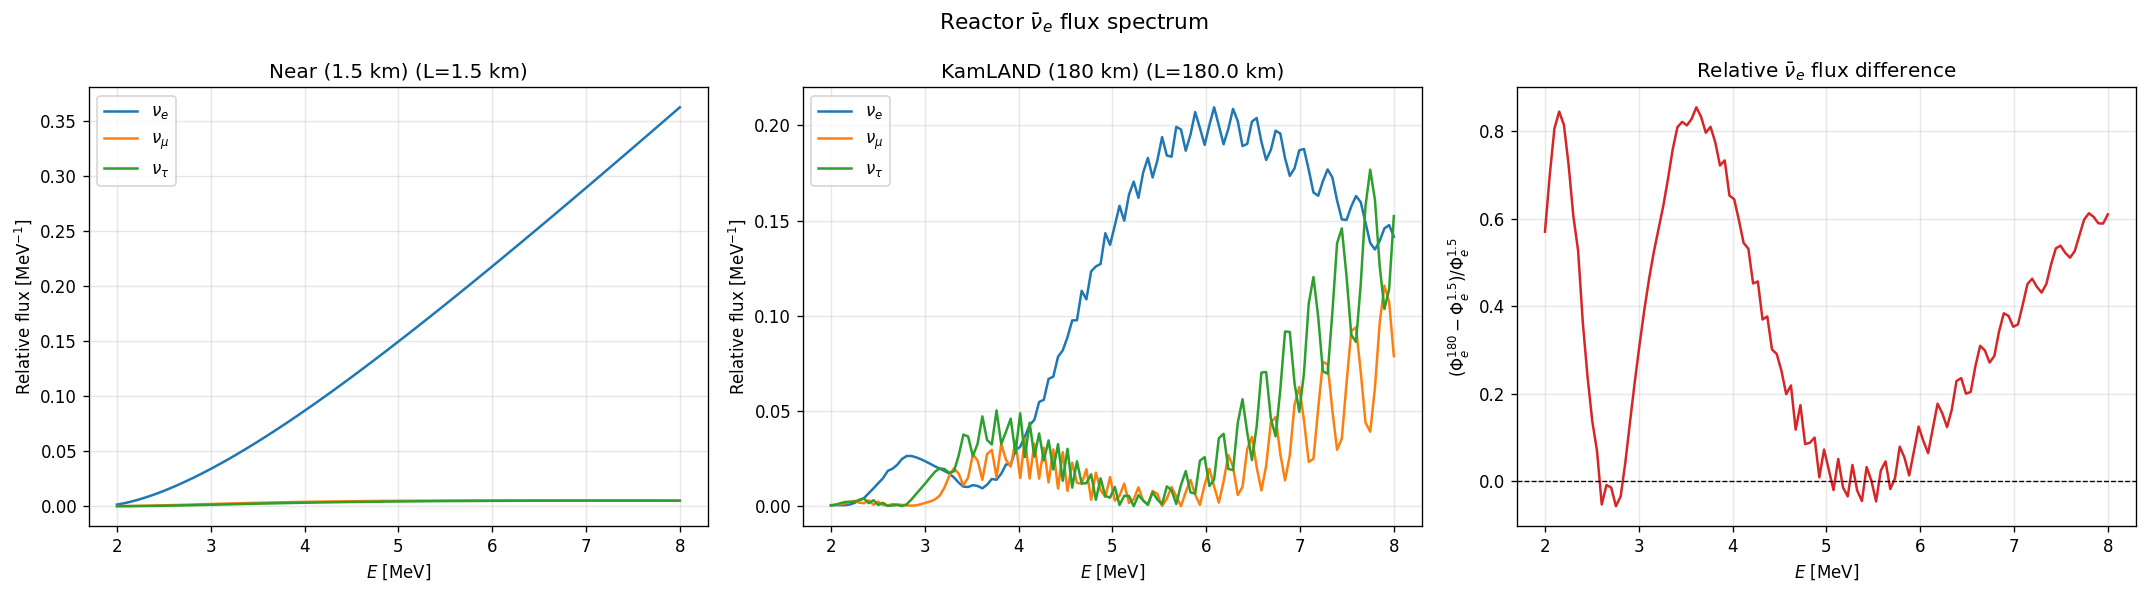

v:\output\analysis\vacuum\vf2_fig33_1_reactor_flux_spectrum.png


In [21]:
E_spec_MeV = np.linspace(2.0, 8.0, 120)
# Vogel-Beacom-inspired shape: dN/dE ∝ (E-1.8)^2 * E^{-1}
spectrum_raw = (E_spec_MeV - 1.8)**2 / E_spec_MeV
spectrum_raw = spectrum_raw / numpy_trapezoid(spectrum_raw, E_spec_MeV)   # normalise

E_t   = torch.tensor(E_spec_MeV, dtype=ctx.dtype, device=ctx.device)
spec_t = torch.tensor(spectrum_raw, dtype=ctx.dtype, device=ctx.device)

# ν̄e initial state (pure flavour state)
nustate_ebar = torch.tensor([1.0 + 0j, 0.0, 0.0], dtype=torch.complex128, device=ctx.device)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
electron_flux = {}
for ax, (name, props) in zip(axes[:2], list(REACTOR_DETECTORS.items())[::2]):  # short baseline and KamLAND
    L_t = torch.tensor(props["L_km"], dtype=ctx.dtype, device=ctx.device)
    flux_arr = to_numpy(vacuum_flux_state(nustate_ebar, osc_bar, E_t, L_t, flux=1.0, spectrum=spec_t, massbasis=False))
    electron_flux[name] = flux_arr[:, 0]
    for i, (label, color) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
        if flux_arr[:, i].max() > 1e-6:
            ax.plot(E_spec_MeV, flux_arr[:, i], label=label, color=color)
    ax.set_xlabel(r"$E$ [MeV]")
    ax.set_ylabel("Relative flux [MeV$^{-1}$]")
    ax.set_title(f"{name} (L={props['L_km']} km)")
    ax.legend()
short_name, kamland_name = list(electron_flux)
relative_difference = (electron_flux[short_name] - electron_flux[kamland_name]) / electron_flux[short_name]
axes[2].plot(E_spec_MeV, relative_difference, color="C3")
axes[2].axhline(0.0, color="black", lw=0.8, ls="--")
axes[2].set_xlabel(r"$E$ [MeV]")
axes[2].set_ylabel(r"$(\Phi_e^{180}-\Phi_e^{1.5})/\Phi_e^{1.5}$")
axes[2].set_title(r"Relative $\bar\nu_e$ flux difference")
fig.suptitle(r"Reactor $\bar\nu_e$ flux spectrum", fontsize=13)
fig.tight_layout()
save_and_show("vf2_fig33_1_reactor_flux_spectrum.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 4. Long-Baseline Accelerator

### 4.1 $\nu_\mu$ Survival at T2K, NOvA, DUNE

$\nu_\mu$ survival probability $P_{\mu\mu}(E)$ at the three long-baseline experiments.

**Expected results:** 
- Each experiment shows a characteristic dip at the oscillation maximum energy $E_{\rm peak}=2(1.2669)|\Delta m^2_{31}|L/\pi$.
- The vacuum formula gives approximately $0.60$, $1.64$, and $2.63\,\mathrm{GeV}$ for T2K, NOvA, and DUNE, respectively.
- The marked vertical line corresponds to the first oscillation maximum, $E_0=E_{\rm peak}$, or equivalently to the first $P_{\mu\mu}$ disappearance minimum. The subsequent minima occur approximately at

$$
E_n=\frac{E_0}{2n+1},\qquad n=0,1,2,\ldots
$$

  Thus, $n=0$ gives the marked minimum at $E_0$, while $n=1,2,\ldots$ produce additional local minima at $E_0/3$, $E_0/5$, and so on. They accumulate towards lower energies because the vacuum oscillation phase grows as $L/E$. The three-flavour interference from $\Delta m^2_{21}$ and the distinction between $\Delta m^2_{31}$ and $\Delta m^2_{32}$ can shift the numerical minima slightly away from this leading atmospheric-scale estimate.

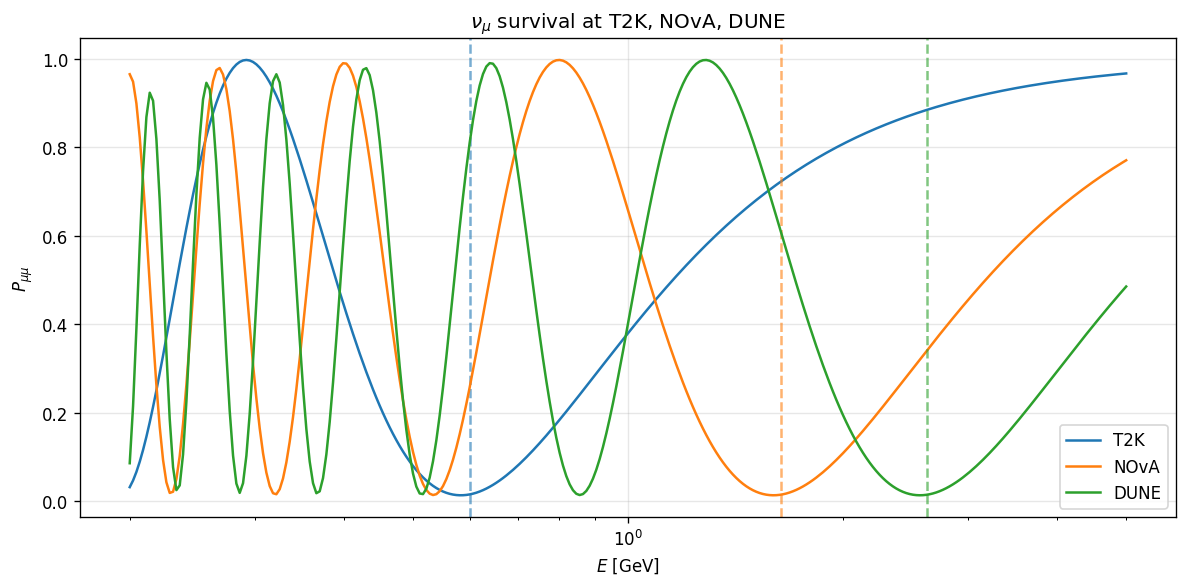

v:\output\analysis\vacuum\vf2_fig41_1_lbl_survival.png


In [12]:
E_lbl = torch.logspace(math.log10(200.0), math.log10(5000.0), 300,
                        dtype=ctx.dtype, device=ctx.device)  # MeV
E_lbl_GeV = to_numpy(E_lbl) * 1e-3

fig, ax = plt.subplots(figsize=(10, 5))
for name, props in EXPERIMENTS.items():
    L_t = torch.tensor(float(props["L_km"]), dtype=ctx.dtype, device=ctx.device)
    P_mm = to_numpy(vacuum_probability_transition(osc, E_lbl, L_t)[:, 1, 1])
    ax.semilogx(E_lbl_GeV, P_mm, label=name, color=props["color"])
    E_max = props["E_peak_GeV"]
    ax.axvline(E_max, color=props["color"], ls="--", alpha=0.6)
    #ax.text(E_max, 1.01, f"{name} peak", color=props["color"], rotation=90, ha="center", va="bottom", transform=ax.get_xaxis_transform())
ax.set_xlabel(r"$E$ [GeV]")
ax.set_ylabel(r"$P_{\mu\mu}$")
ax.set_title(r"$\nu_\mu$ survival at T2K, NOvA, DUNE")
ax.legend()
fig.tight_layout()
save_and_show("vf2_fig41_1_lbl_survival.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 4.2 $\nu_e$ Appearance at T2K, NOvA, DUNE

The $\nu_\mu\rightarrow\nu_e$ appearance probability at the three experiments. The vertical dashed lines mark each
experiment's oscillation maximum energy.

**Expected results:** 
- The $P_{\mu e}$ peak is near the same energy where $P_{\mu\mu}$ shows its minimum.
- The three peak probabilities are of the same order, while their exact positions and shapes differ because each curve uses a different baseline. This probability-only plot does not determine event statistics, which also require the beam exposure, flux, cross section, detector mass, efficiency, and backgrounds.

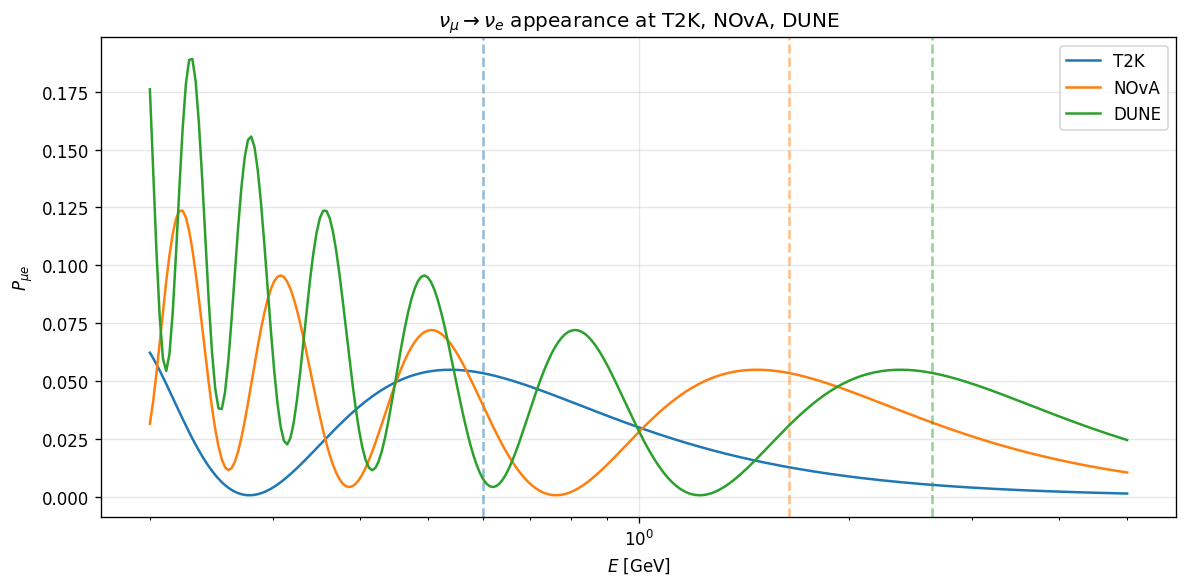

v:\output\analysis\vacuum\vf2_fig42_1_lbl_appearance.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, props in EXPERIMENTS.items():
    L_t   = torch.tensor(float(props["L_km"]), dtype=ctx.dtype, device=ctx.device)
    P_mue = to_numpy(vacuum_probability_transition(osc, E_lbl, L_t)[:, 0, 1])  # P[beta=e, alpha=mu]
    ax.semilogx(E_lbl_GeV, P_mue, label=name, color=props["color"])
    E_max = props["E_peak_GeV"]
    ax.axvline(E_max, color=props["color"], ls="--", alpha=0.5)
ax.set_xlabel(r"$E$ [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title(r"$\nu_\mu \to \nu_e$ appearance at T2K, NOvA, DUNE")
ax.legend()
fig.tight_layout()
save_and_show("vf2_fig42_1_lbl_appearance.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 4.3 DUNE $\nu_e$ Appearance Flux

`vacuum_flux_state` is used to compute the $\nu_e$ appearance flux at the DUNE detector, starting from an
initial $\nu_\mu$ state and a Gaussian beam spectrum centred at 2.4 GeV.

**Expected results:** 
- The oscillated $\nu_e$ flux peaks near the first oscillation maximum energy ($\sim 2$--$3\,\mathrm{GeV}$).
- The $\nu_\mu$ component (survival) shows a corresponding dip.
- Most of the disappearing $\nu_\mu$ flux is converted into $\nu_\tau$ in vacuum; the smaller $\nu_e$ component is the appearance signal highlighted here.

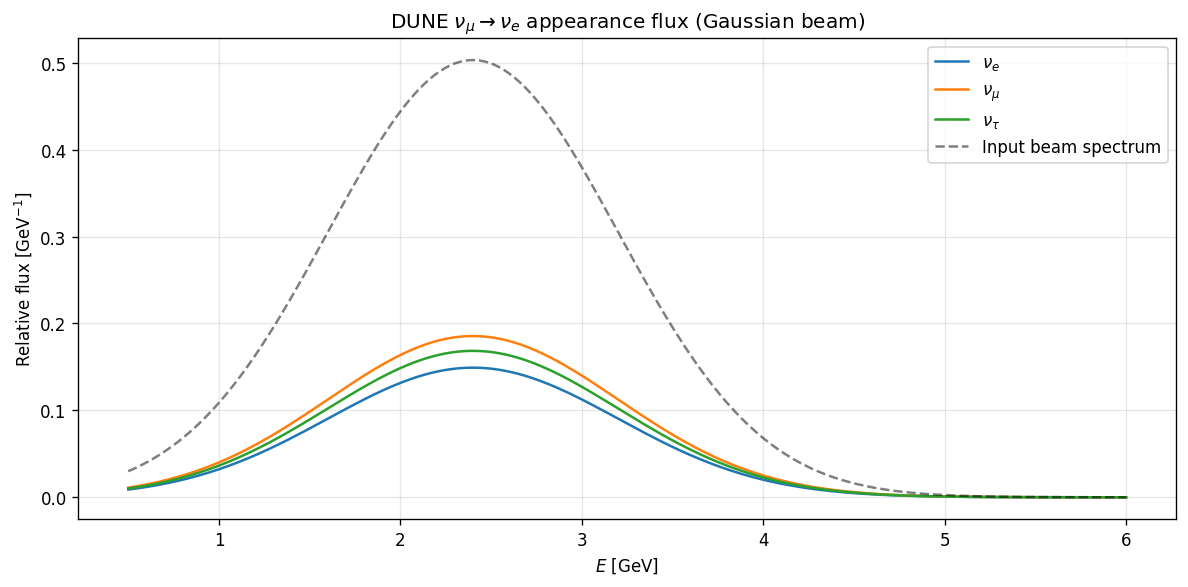

v:\output\analysis\vacuum\vf2_fig43_1_lbl_flux.png


In [9]:
E_dune_GeV = np.linspace(0.5, 6.0, 200)
E_dune_MeV_np = E_dune_GeV * 1e3

# Gaussian beam spectrum centred at 2.4 GeV, width 0.8 GeV
E_beam_center, E_beam_sigma = 2.4, 0.8
spectrum_beam = np.exp(-0.5 * ((E_dune_GeV - E_beam_center) / E_beam_sigma)**2)
spectrum_beam /= numpy_trapezoid(spectrum_beam, E_dune_GeV)

E_t_dune = torch.tensor(E_dune_MeV_np, dtype=ctx.dtype, device=ctx.device)
spec_t_dune = torch.tensor(spectrum_beam, dtype=ctx.dtype, device=ctx.device)

L_dune_t  = torch.tensor(1300.0, dtype=ctx.dtype, device=ctx.device)
nu_mu_state = torch.tensor([0.0 + 0j, 1.0, 0.0], dtype=torch.complex128, device=ctx.device)

flux_dune = to_numpy(vacuum_flux_state(nu_mu_state, osc, E_t_dune, L_dune_t,
                                  flux=1.0, spectrum=spec_t_dune))

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, color) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
    ax.plot(E_dune_GeV, flux_dune[:, i], label=label, color=color)
ax.plot(E_dune_GeV, spectrum_beam, "k--", alpha=0.5, label="Input beam spectrum")
ax.set_xlabel(r"$E$ [GeV]")
ax.set_ylabel("Relative flux [GeV$^{-1}$]")
ax.set_title(r"DUNE $\nu_\mu \to \nu_e$ appearance flux (Gaussian beam)")
ax.legend()
fig.tight_layout()
save_and_show("vf2_fig43_1_lbl_flux.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 5. Atmospheric Neutrinos (Propagating in Vacuum)

### 5.1 $P_{\mu\mu}(E,\cos\theta_z)$ Heatmap

Two-dimensional heatmap of $\nu_\mu$ survival as a function of energy and zenith angle ($\cos\theta_z$). The
baseline is computed from the zenith angle using the atmospheric geometry formula. 

These are atmospheric neutrinos analysed under a vacuum-propagation hypothesis: **neither the atmospheric medium nor the terrestrial matter profile is included**. The geometry sets only the source-to-detector distance.

**Expected results:** 
- For downgoing neutrinos ($\cos\theta_z>0$) the baseline is short and $P_{\mu\mu}\approx 1$.
- For horizontal tracks ($\cos\theta_z\approx 0$) the baseline is $\sim 500\,\mathrm{km}$ and oscillations can appear.
- For upgoing neutrinos ($\cos\theta_z=-1$), $L\approx 12\,740\,\mathrm{km}$ and the probability shows complex multi-frequency oscillations.

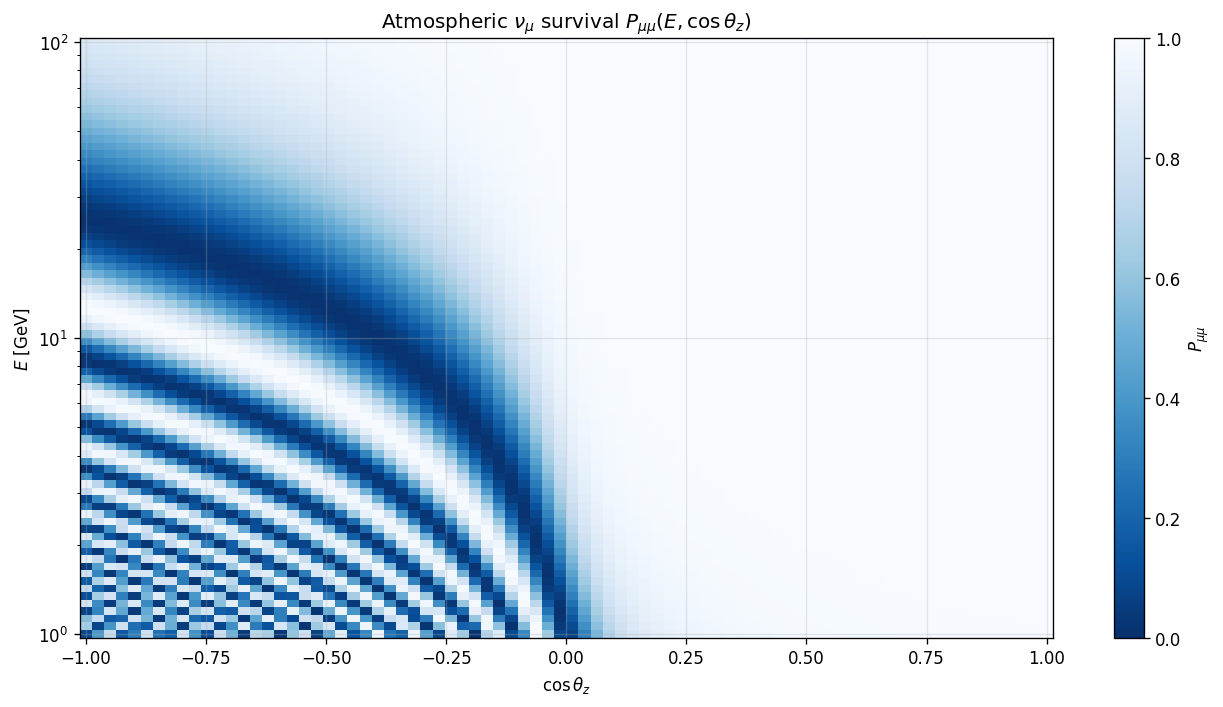

v:\output\analysis\vacuum\vf2_fig51_1_atm_pmu_2d.png


In [10]:
cos_z_vals = np.linspace(-1.0, 1.0, 80)
E_atm_GeV  = np.logspace(0.0, 2.0, 80)   # 1 – 100 GeV
E_atm_MeV  = E_atm_GeV * 1e3

# Compute baselines from zenith angles
L_atm = np.array([baseline_from_zenith(cz) for cz in cos_z_vals])

E_t_atm = torch.tensor(E_atm_MeV, dtype=ctx.dtype, device=ctx.device)
L_t_atm = torch.tensor(L_atm,     dtype=ctx.dtype, device=ctx.device)

# 2-D grid: (NE, 1) × (1, Ncz) → (NE, Ncz, 3, 3)
P_atm = vacuum_probability_transition(osc, E_t_atm[:, None], L_t_atm[None, :])  # (NE, Ncz, 3, 3)
P_mm_atm = to_numpy(P_atm[:, :, 1, 1])   # P_mumu, shape (NE, Ncz)

fig, ax = plt.subplots(figsize=(11, 6))
mesh = ax.pcolormesh(cos_z_vals, E_atm_GeV, P_mm_atm, cmap="Blues_r", vmin=0, vmax=1,
                     shading="auto")
fig.colorbar(mesh, ax=ax, label=r"$P_{\mu\mu}$")
ax.set_yscale("log")
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel(r"$E$ [GeV]")
ax.set_title(r"Atmospheric $\nu_\mu$ survival $P_{\mu\mu}(E, \cos\theta_z)$")
fig.tight_layout()
save_and_show("vf2_fig51_1_atm_pmu_2d.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 5.2 Zenith-Angle Slices

Slices of $P_{\mu\mu}$ and $P_{\mu e}$ vs energy at $\cos\theta_z=-1$ (upward, $L\approx 12\,740\,\mathrm{km}$), $0$ (horizontal,
$L\approx 500\,\mathrm{km}$), and $+0.9$ (downward, $L\approx 20\,\mathrm{km}$).

**Expected results:**
- For the downward-going slice ($\cos\theta_z=+0.9$, $L\approx 20\,\mathrm{km}$), $P_{\mu\mu}\approx 1$ at all energies -- barely any oscillation.
- For the upward-going slice, rapid oscillations driven by $\Delta m^2_{31}$ appear above $\sim 1\,\mathrm{GeV}$, and $\Delta m^2_{21}$ modulates the lower energy range.

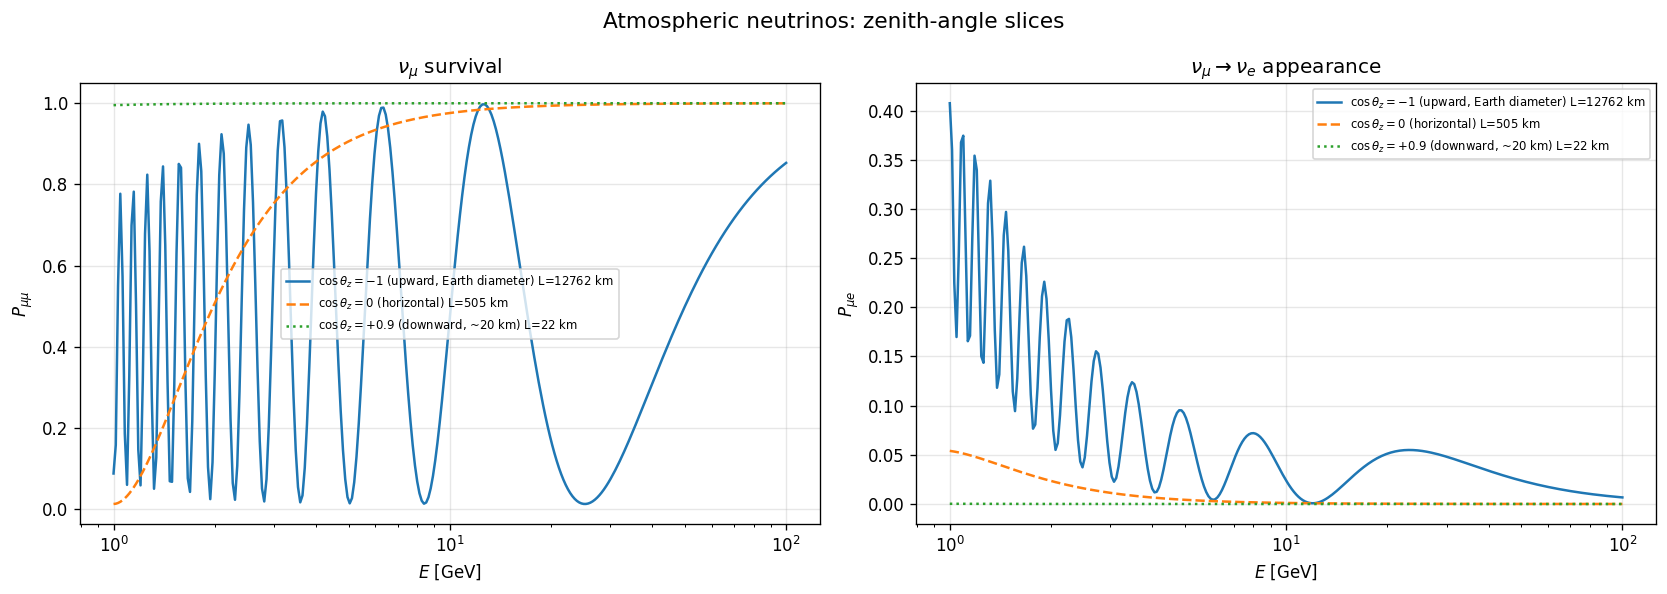

v:\output\analysis\vacuum\vf2_fig52_1_atm_zenith_slices.png


In [11]:
cos_z_slices = {
    r"$\cos\theta_z=-1$ (upward, Earth diameter)": (-1.0, "C0", "-"),
    r"$\cos\theta_z=0$ (horizontal)":              ( 0.0, "C1", "--"),
    r"$\cos\theta_z=+0.9$ (downward, ~20 km)":    ( 0.9, "C2", ":"),
}

E_slice = torch.logspace(0.0, 2.0, 300, dtype=ctx.dtype, device=ctx.device)  # GeV
E_slice_GeV = to_numpy(E_slice)
E_slice_MeV = E_slice * 1e3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, (cz, color, ls) in cos_z_slices.items():
    L_val = baseline_from_zenith(cz)
    L_t   = torch.tensor(L_val, dtype=ctx.dtype, device=ctx.device)
    P_s   = vacuum_probability_transition(osc, E_slice_MeV, L_t)   # (300, 3, 3)
    P_mm  = to_numpy(P_s[:, 1, 1])
    P_me  = to_numpy(P_s[:, 0, 1])
    axes[0].semilogx(E_slice_GeV, P_mm, label=f"{label} L={L_val:.0f} km",
                     color=color, ls=ls)
    axes[1].semilogx(E_slice_GeV, P_me, label=f"{label} L={L_val:.0f} km",
                     color=color, ls=ls)
for ax, title, ylabel in zip(axes,
                               [r"$\nu_\mu$ survival", r"$\nu_\mu \to \nu_e$ appearance"],
                               [r"$P_{\mu\mu}$", r"$P_{\mu e}$"]):
    ax.set_xlabel(r"$E$ [GeV]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7)
fig.suptitle("Atmospheric neutrinos: zenith-angle slices", fontsize=13)
fig.tight_layout()
save_and_show("vf2_fig52_1_atm_zenith_slices.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 6. Summary
| Experiment | Baseline | $E_{\rm peak}$ | $P_{\mu\mu}$ min | $P_{\mu e}$ max |
|---|---|---|---|---|
| Reactor near (1.5 km) | 1.5 km | 3 MeV eff. | $\approx$ 1.0 | -- |
| Medium-baseline reactor example | $50\,\mathrm{km}$ | $3\,\mathrm{MeV}$ eff. | $\approx 0.95$ | -- |
| KamLAND (180 km) | 180 km | 3 MeV eff. | $\approx$ 0.5 | -- |
| T2K | 295 km | 0.6 GeV | $\approx$ 0.05 | $\approx$ 0.05 |
| NOvA | 810 km | 1.8 GeV | $\approx$ 0.05 | $\approx$ 0.07 |
| DUNE | 1300 km | 2.5 GeV | $\approx$ 0.05 | $\approx$ 0.09 |
| Atmospheric (upgoing) | $\sim 12\,740\,\mathrm{km}$ | $1$--$10\,\mathrm{GeV}$ | oscillates | oscillates |

**Physical interpretation:**
- Reactor experiments at short baselines ($\sim 1$--$2\,\mathrm{km}$) measure $\sin^2(2\theta_{13})$ from the disappearance
  dip in the $\bar{\nu}_e$ spectrum. KamLAND at $\sim 180\,\mathrm{km}$ confirmed the Large Mixing Angle (LMA) solution
  with $\Delta m^2_{21}$ from the L/E dependence.
- Long-baseline accelerator experiments tune L/E to the first oscillation maximum. DUNE's
  wide-band beam covers both the first and second maxima, breaking degeneracies between $\delta_{\rm CP}$
  and the mass ordering.
- Atmospheric neutrinos cover a vast range of L/E from 10 m/MeV (downgoing) to 13 000 km/GeV
  (upgoing through Earth), providing sensitivity to both $\Delta m^2_{21}$ and $\Delta m^2_{31}$ simultaneously.
  Matter effects (not included in these vacuum calculations) become important for upgoing
  atmospheric neutrinos above $\sim 5\,\mathrm{GeV}$.